# Read H-Reflex App Data Files

This notebook reads and visualizes data from the **H-Reflex Behavior App** (hreflex_txbdc) binary data files.

**V2 file convention (current):**
- **`.hrs1`** — MH Recruitment Curve stage: sweeps across stimulation intensities to map the M/H-wave recruitment curve.
- **`.hrs2`** — Control Mode stage: stimulates at a fixed user-set intensity (can be changed between trials).
- **`.hrs3`** — Down Condition Pellet (DCP) stage: closed-loop H-reflex conditioning with pellet reward.

**V1 file convention (legacy):**
- **`.hrs1`** — EMG Characterization stage: captures baseline EMG grand-mean distribution.
- **`.hrs2`** — MH Recruitment Curve stage (same binary format as V2 `.hrs1`).

All trial files share the MhRecHeader + MhRecTrial binary format.
EMG data blocks (raw differential, filtered, abs-value) are embedded in every file.

The binary format is based on the `FileIO_Helpers` serialization from the `hreflex_txbdc` package.

# Section 1: Binary File Reader Utilities

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from helpers import (
    # File readers
    read_hrs1, read_hrs2, read_hrs3, read_hrs4, read_hrs5, read_hrs6, read_hrs_ft,
    find_hrs_files, detect_app_version,
    # Summary printers
    print_hrs1_summary, print_hrs2_summary,
    # HRS2 plots
    plot_amplitude_distribution, plot_background_emg_views, plot_hrs2_analysis,
    plot_actual_trial_timeline, plot_mwave_control_error, plot_frequency_test,
    # SNR analysis
    compute_snr_analysis, compute_mra_snr_analysis,
    plot_hrs2_trials, classify_trials, get_trial_window,
    detect_stim_onset, get_trial_context_window,
    detect_and_correct_failed_trials,
    # Post-hoc global windowing analysis
    analyze_global_background, run_threshold_sweep, plot_threshold_sweep,
    split_trials_by_polarity, plot_hm_ratio_summary, plot_hwave_regression,
    # Constants
    SAMPLE_RATE, BIN_DURATION_MS, BIN_SAMPLES, TRIAL_RECORD_MS,
    STIM_ONSET_THRESHOLD, STIM_END_THRESHOLD,
    build_merged_amp_groups,
)

print("Helpers loaded.")
print(f"  App constants: SAMPLE_RATE={SAMPLE_RATE} Hz | BIN={BIN_DURATION_MS} ms ({BIN_SAMPLES} samples) | TRIAL_RECORD={TRIAL_RECORD_MS} ms")
print(f"  Stim thresholds: onset >= {STIM_ONSET_THRESHOLD} V | end < {STIM_END_THRESHOLD} V")

Helpers loaded.
  App constants: SAMPLE_RATE=5000.0 Hz | BIN=50 ms (250 samples) | TRIAL_RECORD=100 ms
  Stim thresholds: onset >= 4.5 V | end < 1.9 V


# Section 1b: Auto-Detect Recording Files

Set `recording_dir` to the path of your recording folder.  
The `.hrs1` and `.hrs2` files will be found automatically.

In [2]:
# "HRPilot-17_Control/CC1_HRPILOT-17_BOOTH1_500US_6-30-26"
# "HRPilot-17_Control/CC2_HRPILOT-17_BOOTH1_500US_7-2-26"
# "HRPilot-17_Control/CC3_HR-PILOT-17_BOOTH1_500US_7-3-26"
# "HRPilot-17_Control/CC4_HR-PILOT-17_BOOTH1_500US_7-6-26"
# "HRPilot-17_Control/CC5_HRPILOT-17_BOOTH1_500US_7-8-26"
# "HRPilot-17_Control/CC6_HRPILOT-17_BOOTH1_500US_7-10-26"
# "HRPilot-17_Control/HRPILOT-17_M-WAVE_ALGORITHM_TEST_BOOTH1_7-14-26"
# "HRPilot-17_Control/HRPILOT-17_CONTROL_BOOTH1_250US_7-16-26"
# "HRPilot-17_Control/HRPILOT-17_CONTROL2_BOOTH1_250US_10KHZ_7-17-26"
# "HRPilot-17_Control/HRPILOT-17_CONTROL3_BOOTH1_250US_10KHZ_7-21-26"
# "HRPilot-17_Control/HRPILOT-17_CONTROL4_BOOTH1_250US_10KHZ_7-22-26"

recording_dir         = "HRPilot-17_Control/HRPILOT-17_CONTROL4_BOOTH1_250US_10KHZ_7-22-26"
recording_sample_rate = 10000.0  # Set to e.g. 5000.0 or 10000.0 to override; None = auto-detect

hrs1_path, hrs2_path, hrs3_path, hrs4_path, hrs5_path, hrs6_path, hrsft_path = find_hrs_files(recording_dir)
_app_version = detect_app_version(recording_dir)
print(f"H-Reflex App V{_app_version}  |  "
      f"hrs1={os.path.basename(hrs1_path)  if hrs1_path  else chr(8211)}  "
      f"hrs2={os.path.basename(hrs2_path)  if hrs2_path  else chr(8211)}  "
      f"hrs3={os.path.basename(hrs3_path)  if hrs3_path  else chr(8211)}  "
      f"hrs4={os.path.basename(hrs4_path)  if hrs4_path  else chr(8211)}  "
      f"hrs5={os.path.basename(hrs5_path)  if hrs5_path  else chr(8211)}  "
      f"hrs6={os.path.basename(hrs6_path)  if hrs6_path  else chr(8211)}  "
      f"hrsft={os.path.basename(hrsft_path) if hrsft_path else chr(8211)}")

H-Reflex App V3  |  hrs1=–  hrs2=HRPILOT-17_CONTROL4_BOOTH1_250US_10KHZ_7-22-26_20260722T094336.hrs2  hrs3=–  hrs4=–  hrs5=–  hrs6=–  hrsft=–


In [3]:
# --- Load all data files (auto-detects V1 / V2 / V3 app) ----------------------
cm_header  = cm_trials  = cm_emg_blocks  = None   # V2/V3 Control Mode
dcp_header = dcp_trials = dcp_emg_blocks = None   # V2/V3 Down Condition Pellet
s4_header  = s4_trials  = s4_emg_blocks  = None   # V3 Up Condition Pellet  (.hrs4)
s5_header  = s5_trials  = s5_emg_blocks  = None   # V3 Down Condition VNS   (.hrs5)
s6_header  = s6_trials  = s6_emg_blocks  = None   # V3 Up Condition VNS     (.hrs6)
ft_header  = ft_trials  = ft_emg_blocks  = None   # V3 Frequency Test       (.hrsft)

if _app_version == 1:
    # V1: S1=EMG Characterization (.hrs1)  S2=MH Recruitment Curve (.hrs2)
    if hrs1_path:
        hrs1_header, hrs1_trials, hrs1_emg_blocks = read_hrs1(hrs1_path)
        print_hrs1_summary(hrs1_header, hrs1_trials, hrs1_emg_blocks, hrs1_path)
    else:
        print("No .hrs1 file found — EMG Characterization data unavailable.")
        hrs1_header, hrs1_trials, hrs1_emg_blocks = None, [], []
    if hrs2_path:
        hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs2_path)
        print_hrs2_summary(hrs2_header, hrs2_trials, hrs2_emg_blocks, hrs2_path)
    else:
        print("No .hrs2 file found — MH Recruitment data unavailable.")
        hrs2_header, hrs2_trials, hrs2_emg_blocks = None, [], []
else:
    # V2/V3: S1=MH Recruitment (.hrs1)  S2=Control Mode (.hrs2)  S3=DCP (.hrs3)
    #        V3 adds: S4 (.hrs4)  S5 (.hrs5)  S6 (.hrs6)  FT (.hrsft)
    if hrs1_path:
        hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs1_path)
        hrs1_header = hrs2_header
        hrs1_trials, hrs1_emg_blocks = [], []
        print_hrs2_summary(hrs2_header, hrs2_trials, hrs2_emg_blocks, hrs1_path)
    else:
        print("No .hrs1 file found — MH Recruitment data unavailable.")
        hrs1_header = hrs2_header = None
        hrs1_trials = hrs2_trials = []
        hrs1_emg_blocks = hrs2_emg_blocks = []
    if hrs2_path:
        cm_header, cm_trials, cm_emg_blocks = read_hrs2(hrs2_path)
        print(f"Control Mode:           {len(cm_trials)} trials")
    else:
        print("No .hrs2 file found — Control Mode data unavailable.")
    if hrs3_path:
        dcp_header, dcp_trials, dcp_emg_blocks = read_hrs3(hrs3_path)
        print(f"Down Condition Pellet:  {len(dcp_trials)} trials")
    else:
        print("No .hrs3 file found — Down Condition Pellet data unavailable.")
    if hrs4_path:
        s4_header, s4_trials, s4_emg_blocks = read_hrs4(hrs4_path)
        print(f"Up Condition Pellet:    {len(s4_trials)} trials")
    if hrs5_path:
        s5_header, s5_trials, s5_emg_blocks = read_hrs5(hrs5_path)
        print(f"Down Condition VNS:     {len(s5_trials)} trials")
    if hrs6_path:
        s6_header, s6_trials, s6_emg_blocks = read_hrs6(hrs6_path)
        print(f"Up Condition VNS:       {len(s6_trials)} trials")
    if hrsft_path:
        ft_header, ft_trials, ft_emg_blocks = read_hrs_ft(hrsft_path)
        print(f"Frequency Test:         {len(ft_trials)} trials")

# V2/V3 Control Mode-only: alias hrs2_trials ← cm_trials so downstream cells work.
if _app_version in (2, 3) and not hrs2_trials and cm_trials:
    hrs2_header     = cm_header
    hrs2_trials     = cm_trials
    hrs2_emg_blocks = cm_emg_blocks
    hrs1_header     = hrs2_header
    print('Note: Control Mode trials used as primary analysis (no Recruitment Curve stage).')

if hrs1_header is None:
    class _SampleRateStub:
        sample_rate = recording_sample_rate or 5000.0
    hrs1_header = _SampleRateStub()

No .hrs1 file found — MH Recruitment data unavailable.
Control Mode:           701 trials
No .hrs3 file found — Down Condition Pellet data unavailable.
Note: Control Mode trials used as primary analysis (no Recruitment Curve stage).


# Section 3: Peri-Stimulus Trials — MH Recruitment Curve or Control Mode

For **V2** recordings `hrs2_trials` contains whichever stage was run:
- `.hrs1` present → MH Recruitment Curve trials
- `.hrs1` absent, `.hrs2` present → Control Mode trials (aliased automatically)

For **V1** recordings `hrs2_trials` contains the MH Recruitment Curve trials from `.hrs2`.

In [16]:
# Data already loaded in the cell above.
# hrs1_trials = MH Recruitment Curve trials (V2 or V3)).
# hrs2_trials = Control Mode (V2 or V3).
print(f"MH Recruitment trials : {len(hrs1_trials)}"
      + (f"  |  Control Mode: {len(hrs2_trials)}" if hrs2_trials  is not None else "")
      + (f"  |  DCP: {len(dcp_trials)}"         if dcp_trials is not None else ""))


MH Recruitment trials : 0  |  Control Mode: 701


Available stages:
  'control_mode'         → Control Mode (.hrs2)  (701 trials)  ◄ active

Active : Control Mode (.hrs2)  ·  701 trials
(Change ACTIVE_STAGE above + re-run this cell only when switching stages for Post-Hoc analysis.)

── Histogram: Control Mode (.hrs2)  (701 trials)


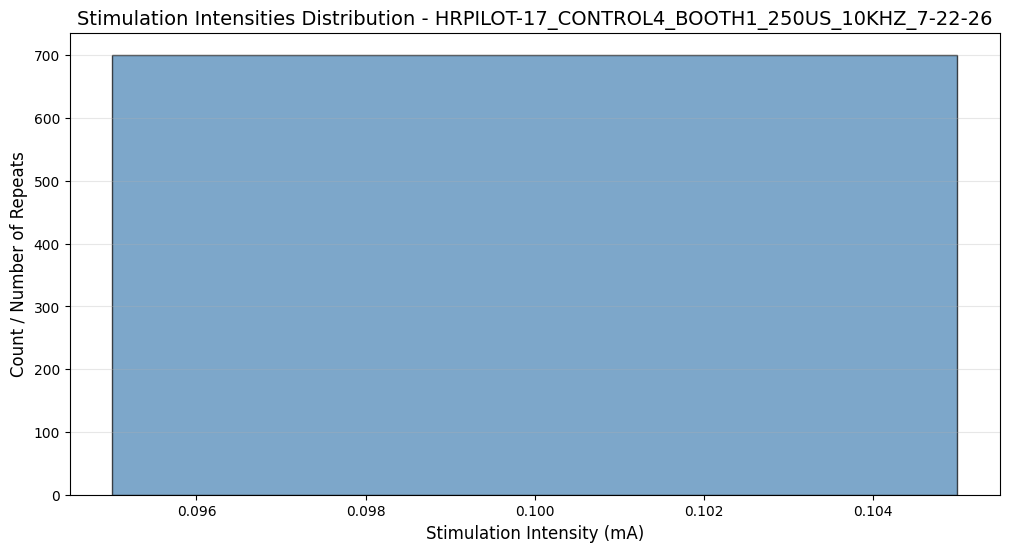

In [17]:
# ── Stage Selector + Stimulation Intensity Histogram ──────────────────────────
# ACTIVE_STAGE controls which stage the Post-Hoc notebook uses.
# All viewer cells show a Stage dropdown when multiple stages are loaded.

_stage_map = {}
if hrs2_trials and (not cm_trials or hrs2_trials is not cm_trials):
    _stage_map['mh_recruitment'] = (hrs2_trials, hrs2_header, hrs2_emg_blocks,
                                     'MH Recruitment Curve (.hrs1)')
if cm_trials:
    _stage_map['control_mode']   = (cm_trials,   cm_header,   cm_emg_blocks,
                                     'Control Mode (.hrs2)')
if dcp_trials:
    _stage_map['dcp']            = (dcp_trials,  dcp_header,  dcp_emg_blocks,
                                     'Down Condition Pellet (.hrs3)')
if s4_trials:
    _stage_map['up_cond_pellet'] = (s4_trials,   s4_header,   s4_emg_blocks,
                                     'Up Condition Pellet (.hrs4)')
if s5_trials:
    _stage_map['down_cond_vns']  = (s5_trials,   s5_header,   s5_emg_blocks,
                                     'Down Condition VNS (.hrs5)')
if s6_trials:
    _stage_map['up_cond_vns']    = (s6_trials,   s6_header,   s6_emg_blocks,
                                     'Up Condition VNS (.hrs6)')

ACTIVE_STAGE = next(iter(_stage_map))
# ACTIVE_STAGE = 'mh_recruitment'
# ACTIVE_STAGE = 'control_mode'
# ACTIVE_STAGE = 'dcp'
# ACTIVE_STAGE = 'up_cond_pellet'
# ACTIVE_STAGE = 'down_cond_vns'
# ACTIVE_STAGE = 'up_cond_vns'

if ACTIVE_STAGE not in _stage_map:
    ACTIVE_STAGE = next(iter(_stage_map))
    print(f'Note: requested stage not available; defaulting to {ACTIVE_STAGE!r}')

_sel = _stage_map[ACTIVE_STAGE]
_plot_trials, _plot_header, _plot_emg_blocks = _sel[0], _sel[1], _sel[2]

print('Available stages:')
for _k, (_t, _h, _e, _lbl) in _stage_map.items():
    _mark = '  ◄ active' if _k == ACTIVE_STAGE else ''
    print(f'  {_k!r:<22} → {_lbl}  ({len(_t)} trials){_mark}')
print(f'\nActive : {_sel[3]}  ·  {len(_plot_trials)} trials')
print('(Change ACTIVE_STAGE above + re-run this cell only when switching stages for Post-Hoc analysis.)')

# ── Stimulation Intensity Histogram ───────────────────────────────────────
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp

_hist_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _stage_map.items() if _t]
if len(_hist_opts) == 1:
    _sk, (_st, _sh, _se, _slbl) = next(iter(_stage_map.items()))
    print(f'\n── Histogram: {_slbl}  ({len(_st)} trials)')
    plot_amplitude_distribution(_st, _sh)
else:
    _hist_out  = Output()
    _hist_drop = Dropdown(options=_hist_opts, description='Stage:', layout={'width': '440px'})
    def _hist_show(change=None):
        _st, _sh, _se, _slbl = _stage_map[_hist_drop.value]
        with _hist_out:
            _hist_out.clear_output(wait=True)
            print(f'\n── Histogram: {_slbl}  ({len(_st)} trials)')
            plot_amplitude_distribution(_st, _sh)
    _hist_drop.observe(_hist_show, names='value')
    _disp(VBox([_hist_drop, _hist_out]))
    _hist_show()


── Trial Timeline: Control Mode (.hrs2)  (701 trials)
Actual trial timeline (701 trials)
  Recording span : 16835.2 s  (4.676 h)
  Trial rate     : 149.9 trials / hour
  ITI — mean: 24050 ms  |  median: 5982 ms  |  min: 4950 ms  |  max: 334698 ms


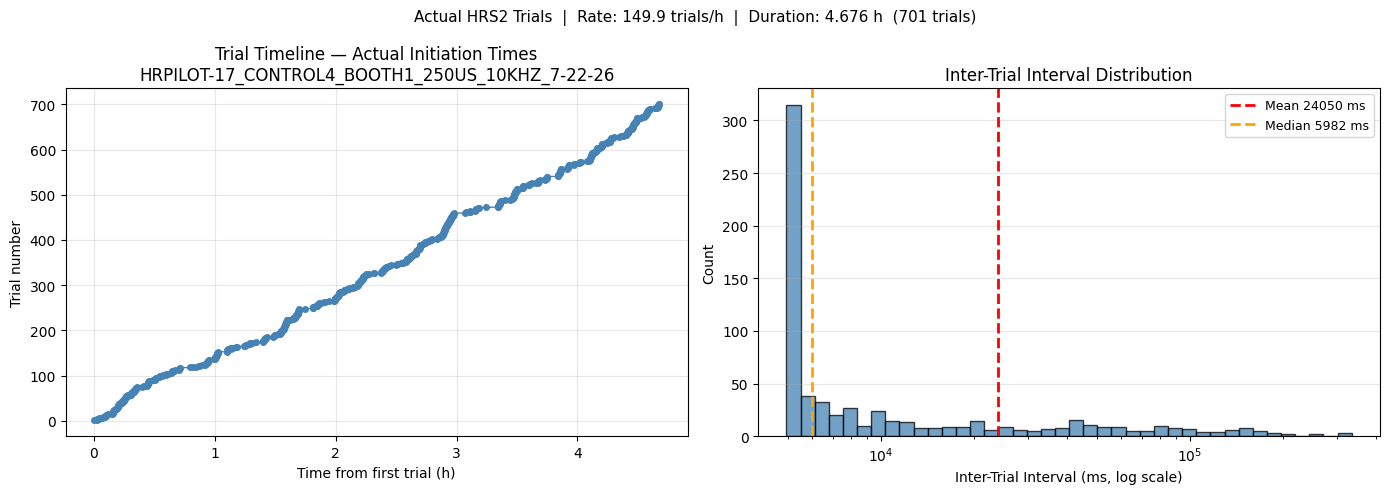

In [18]:
# ── Trial Timeline ─────────────────────────────────────────────────────────
# Shows trial number vs. actual wall-clock time and inter-trial interval (ITI)
# distribution for each recording stage.
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp

_tl_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _stage_map.items() if _t]
if len(_tl_opts) == 1:
    _sk, (_st, _sh, _se, _slbl) = next(iter(_stage_map.items()))
    print(f'\n── Trial Timeline: {_slbl}  ({len(_st)} trials)')
    plot_actual_trial_timeline(_st, header=_sh)
else:
    _tl_out  = Output()
    _tl_drop = Dropdown(options=_tl_opts, description='Stage:', layout={'width': '440px'})
    def _tl_show(change=None):
        _st, _sh, _se, _slbl = _stage_map[_tl_drop.value]
        with _tl_out:
            _tl_out.clear_output(wait=True)
            print(f'\n── Trial Timeline: {_slbl}  ({len(_st)} trials)')
            plot_actual_trial_timeline(_st, header=_sh)
    _tl_drop.observe(_tl_show, names='value')
    _disp(VBox([_tl_drop, _tl_out]))
    _tl_show()


# Section 3b: "Most Recent Background" + "Background EMG Level"

Recreates the H-Reflex App recruitment-curve trial-plot widgets from `MhRecruitmentCurveStage.get_trial_plot_options`:

- **Most recent background** bar chart of the pre-stim |EMG| bins.
- **EMG Level** scatter of background grand means across trials.

Bins are reconstructed from `hrs2_emg_blocks` over a fixed monitoring window (default 2500 ms ending at trigger time).

In [7]:
# ── Background EMG Views ──────────────────────────────────────────────────
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp

_bg_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _stage_map.items() if _t]
if len(_bg_opts) == 1:
    _sk, (_st, _sh, _se, _slbl) = next(iter(_stage_map.items()))
    print(f'\n── Background EMG: {_slbl}  ({len(_st)} trials)')
    plot_background_emg_views(_st, _se, monitoring_window_ms=2500)
else:
    _bg_out  = Output()
    _bg_drop = Dropdown(options=_bg_opts, description='Stage:', layout={'width': '440px'})
    def _bg_show(change=None):
        _st, _sh, _se, _slbl = _stage_map[_bg_drop.value]
        with _bg_out:
            _bg_out.clear_output(wait=True)
            print(f'\n── Background EMG: {_slbl}  ({len(_st)} trials)')
            plot_background_emg_views(_st, _se, monitoring_window_ms=2500)
    _bg_drop.observe(_bg_show, names='value')
    _disp(VBox([_bg_drop, _bg_out]))
    _bg_show()



── Background EMG: Control Mode (.hrs2)  (701 trials)
701 trials used stored bins  |  0 trials reconstructed from emg_blocks.


# Section 6: HRS2 Detailed Analysis

Interactive averaged-waveform paged grid (with M/H peak markers and signal overlays) plus the normalized and raw recruitment curves. The cell below sets the analysis parameters; the cell after that calls `plot_hrs2_analysis`.

In [8]:
#  Configuration 
PRE_PLOT_MS  = 5   # ms before stim onset to display
POST_PLOT_MS = 25  # ms after  stim onset to display
N_PER_PAGE   = 6   # trials shown per page (2 rows x 3 cols)

# M/H wave window constants (ms relative to stim onset)
#M_WAVE_START_MS = 3
#M_WAVE_END_MS= 5.5
#H_WAVE_START_MS = 9.0
#H_WAVE_END_MS   = 12

M_WAVE_START_MS = 1.8 
M_WAVE_END_MS= 5 
H_WAVE_START_MS = 6.5   
H_WAVE_END_MS   = 11

PRE_AVG_MS  = 5   # ms before stim onset
POST_AVG_MS = 25  # ms after  stim onset
N_PER_PAGE  = 6   # amplitude groups per page (2 rows x 3 cols)


In [19]:
# ── Optional: Merged Amplitude Group Analysis ─────────────────────────────
# MERGE_ALL = True  →  collapse every amplitude into a single group.
#
# MERGED_GROUPS accepts two styles (mix freely):
#   Explicit list : [0.12, 0.13, 0.15]   — merge exactly those amplitudes
#   Range tuple   : (0.10, 0.50)         — merge all amplitudes where low <= amp <= high
#
# Examples:
#   MERGED_GROUPS = [[0.12, 0.13], [0.15, 0.16, 0.17]]   ← two explicit groups
#   MERGED_GROUPS = [(0.10, 0.20), (0.25, 0.40)]          ← two range groups
#   MERGED_GROUPS = [(0.10, 0.20), [0.50, 0.55]]          ← range + explicit, mixed
#
# Leave both flags at their defaults to use the standard (unmerged) grouping.
MERGE_ALL     = True   # True → collapse every amplitude into one group
MERGED_GROUPS = []
#[(0,0.108), (0.108,0.23), (0.23,0.43), (0.43,0.50), (0.50,0.60), (0.60,0.70)]
#[(0,0.108), (0.108,0.20), (0.20,0.30), (0.30,0.40), (0.40,0.50), (0.50,0.60), (0.60,0.70)]  # Example: merge amplitudes into ranges

def _resolve_groups(trials, groups):
    _all_amps = sorted({t.stimulation_amplitude_ma for t in trials})
    resolved = []
    for g in groups:
        if isinstance(g, tuple) and len(g) == 2:
            lo, hi = float(g[0]), float(g[1])
            matched = [a for a in _all_amps if lo <= a <= hi]
            if matched:
                resolved.append(matched)
            else:
                print(f'Warning: range ({lo}, {hi}) matched no amplitudes — skipped.')
        else:
            resolved.append(list(g))
    return resolved

def _apply_merge(trials):
    if MERGE_ALL:
        _amps = sorted({t.stimulation_amplitude_ma for t in trials})
        return build_merged_amp_groups(trials, [_amps])
    if MERGED_GROUPS:
        return build_merged_amp_groups(trials, _resolve_groups(trials, MERGED_GROUPS))
    return trials

_hrs2_trials_plot = _apply_merge(_plot_trials)


Merged group ['0.100'] mA -> avg 0.100 mA, 701 trials


In [10]:
# ── HRS2 Analysis: Interactive Averaged Waveforms + Recruitment Curve ─────
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp

_ana_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _stage_map.items() if _t]
if len(_ana_opts) == 1:
    _sk, (_st, _sh, _se, _slbl) = next(iter(_stage_map.items()))
    _tp = _apply_merge(_st)
    print(f'\n── Analysis: {_slbl}  ({len(_st)} trials)')
    plot_hrs2_analysis(
        _tp, _sh,
        pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
        n_per_page=N_PER_PAGE,
        m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
        h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
        sample_rate=recording_sample_rate or hrs1_header.sample_rate,
        emg_blocks=_se,
    )
else:
    _ana_out  = Output()
    _ana_drop = Dropdown(options=_ana_opts, description='Stage:', layout={'width': '440px'})
    def _ana_show(change=None):
        _st, _sh, _se, _slbl = _stage_map[_ana_drop.value]
        _tp = _apply_merge(_st)
        with _ana_out:
            _ana_out.clear_output(wait=True)
            print(f'\n── Analysis: {_slbl}  ({len(_st)} trials)')
            plot_hrs2_analysis(
                _tp, _sh,
                pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
                n_per_page=N_PER_PAGE,
                m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
                h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
                sample_rate=recording_sample_rate or hrs1_header.sample_rate,
                emg_blocks=_se,
            )
    _ana_drop.observe(_ana_show, names='value')
    _disp(VBox([_ana_drop, _ana_out]))
    _ana_show()


Merged group ['0.100'] mA -> avg 0.100 mA, 701 trials

── Analysis: Control Mode (.hrs2)  (701 trials)
Loaded 1 amplitude groups across 1 page(s).
Double-click a subplot to zoom in. Ctrl-click to select multiple signals.


Output()

c:\Users\dal866445\Documents\Github\open-ephys-python-tools\.venv\Lib\site-packages\scipy\interpolate\_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


HTML(value='<hr><b>Background EMG — selected amplitude / polarity group</b>')

Output()

HTML(value='<hr><b>H-wave Regression — selected amplitude / polarity group</b>')

Output()

In [11]:
# ── HRS2 Trial Viewer: Interactive Per-Trial Grid + Zoom ─────────────────
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp

_trv_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _stage_map.items() if _t]
if len(_trv_opts) == 1:
    _sk, (_st, _sh, _se, _slbl) = next(iter(_stage_map.items()))
    _tp = _apply_merge(_st)
    print(f'\n── Trial Viewer: {_slbl}  ({len(_st)} trials)')
    plot_hrs2_trials(
        _tp, _sh,
        pre_plot_ms=PRE_PLOT_MS, post_plot_ms=POST_PLOT_MS,
        n_per_page=N_PER_PAGE,
        m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
        h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
        sample_rate=recording_sample_rate or hrs1_header.sample_rate,
        emg_blocks=_se,
    )
else:
    _trv_out  = Output()
    _trv_drop = Dropdown(options=_trv_opts, description='Stage:', layout={'width': '440px'})
    def _trv_show(change=None):
        _st, _sh, _se, _slbl = _stage_map[_trv_drop.value]
        _tp = _apply_merge(_st)
        with _trv_out:
            _trv_out.clear_output(wait=True)
            print(f'\n── Trial Viewer: {_slbl}  ({len(_st)} trials)')
            plot_hrs2_trials(
                _tp, _sh,
                pre_plot_ms=PRE_PLOT_MS, post_plot_ms=POST_PLOT_MS,
                n_per_page=N_PER_PAGE,
                m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
                h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
                sample_rate=recording_sample_rate or hrs1_header.sample_rate,
                emg_blocks=_se,
            )
    _trv_drop.observe(_trv_show, names='value')
    _disp(VBox([_trv_drop, _trv_out]))
    _trv_show()


Merged group ['0.100'] mA -> avg 0.100 mA, 701 trials

── Trial Viewer: Control Mode (.hrs2)  (701 trials)
Loaded 701 trials across 117 page(s).
Sample rate: 10000 Hz  |  ms/sample: 0.1000
Stim waveform: available
Double-click a subplot to zoom in, or use the dropdown + 'View trial' button.


HTML(value='<hr><b>Background EMG — selected group</b>')

Output()

HTML(value='<hr><b>H:M Ratio Summary — selected group</b>')

Output()

HTML(value='<hr><b>H-wave Regression — selected group</b>')

Output()

# Section 3c: H:M Ratio Summary

Box plot and histogram of H:M ratio for each stimulation polarity group.
If both normal and reversed polarities were used in this session, each group is analysed separately.


── Polarity / H:M Ratio: Control Mode (.hrs2)  (701 trials)


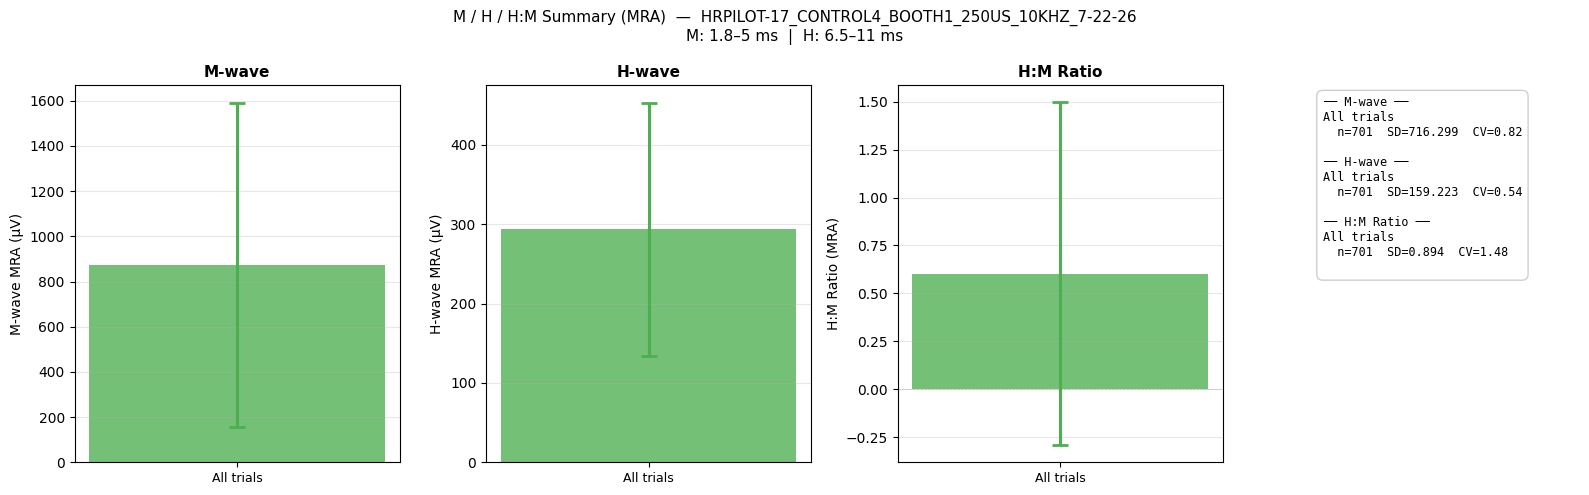

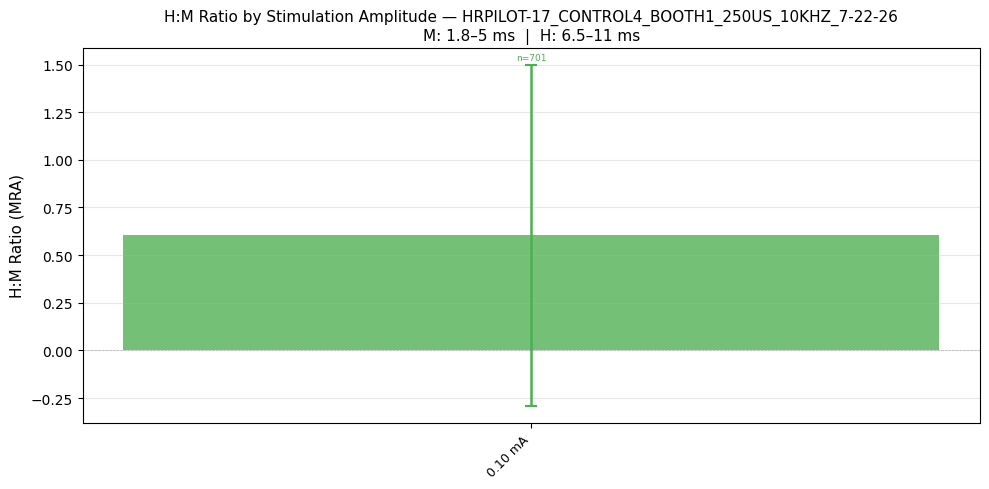

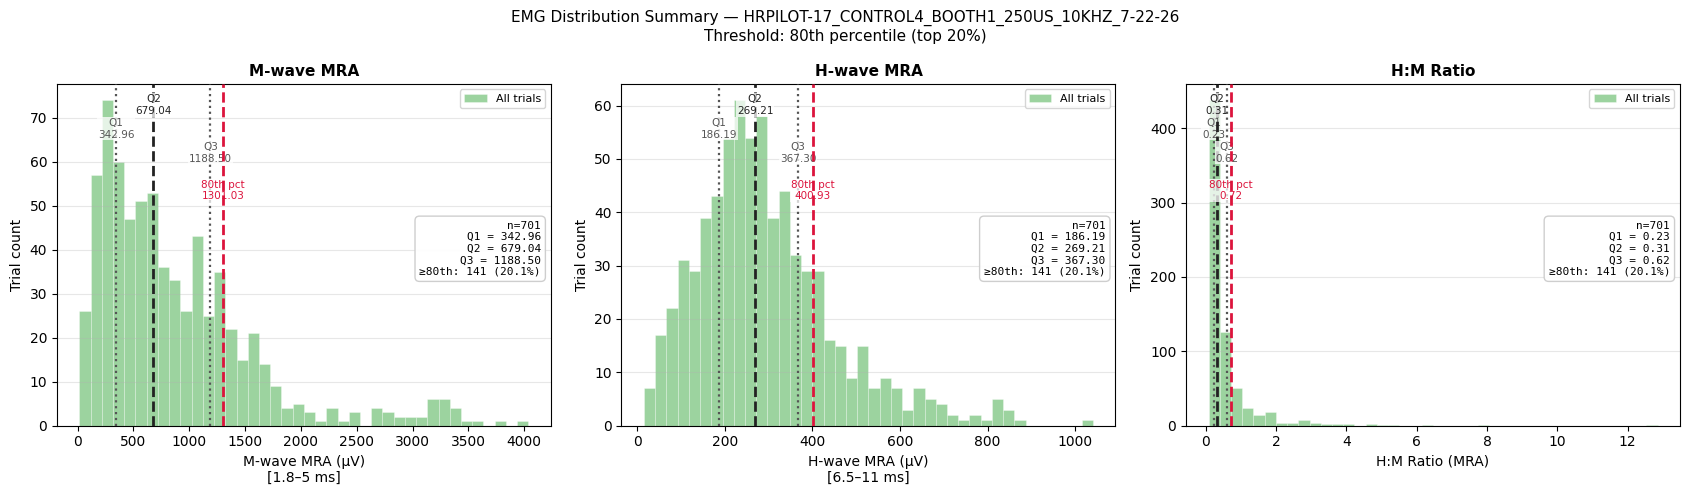

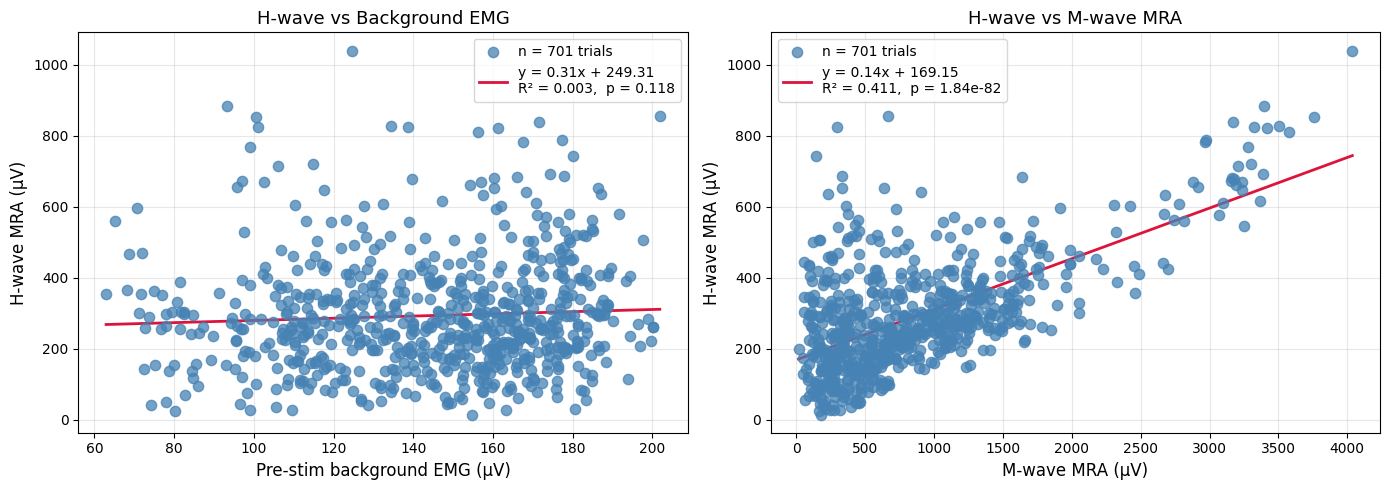

  Regression (n=701):  slope=0.3086  intercept=249.31  R²=0.0035  p=0.1182


In [12]:
# ── Stim Polarity Analysis ───────────────────────────────────────────────
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp

_pol_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _stage_map.items() if _t]
if len(_pol_opts) == 1:
    _sk, (_st, _sh, _se, _slbl) = next(iter(_stage_map.items()))
    print(f'\n── Polarity / H:M Ratio: {_slbl}  ({len(_st)} trials)')
    trials_by_polarity = split_trials_by_polarity(_st)
    plot_hm_ratio_summary(
        trials_by_polarity, _sh,
        m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
        h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
        sample_rate=recording_sample_rate or hrs1_header.sample_rate,
        pre_ms=PRE_AVG_MS, post_ms=POST_AVG_MS,
    )
    plot_hwave_regression(
        _st, _se,
        m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
        h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
        sample_rate=recording_sample_rate or hrs1_header.sample_rate,
        pre_ms=PRE_AVG_MS, post_ms=POST_AVG_MS,
    )
else:
    _pol_out  = Output()
    _pol_drop = Dropdown(options=_pol_opts, description='Stage:', layout={'width': '440px'})
    def _pol_show(change=None):
        _st, _sh, _se, _slbl = _stage_map[_pol_drop.value]
        with _pol_out:
            _pol_out.clear_output(wait=True)
            print(f'\n── Polarity / H:M Ratio: {_slbl}  ({len(_st)} trials)')
            trials_by_polarity = split_trials_by_polarity(_st)
            plot_hm_ratio_summary(
                trials_by_polarity, _sh,
                m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
                h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
                sample_rate=recording_sample_rate or hrs1_header.sample_rate,
                pre_ms=PRE_AVG_MS, post_ms=POST_AVG_MS,
            )
            plot_hwave_regression(
                _st, _se,
                m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
                h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
                sample_rate=recording_sample_rate or hrs1_header.sample_rate,
                pre_ms=PRE_AVG_MS, post_ms=POST_AVG_MS,
            )
    _pol_drop.observe(_pol_show, names='value')
    _disp(VBox([_pol_drop, _pol_out]))
    _pol_show()


# Section 3d: M-Wave Stabilization Control Error (V3 S2 / S4 / S5 / S6)

Plots the M-wave stabilization controller output trial-by-trial.
- **Left axis** — `m_wave_error` (µV): difference between actual M-wave and the target set-point; falls back to `m_wave_window_median` when the controller was inactive.
- **Right axis** — `stimulation_amplitude_ma` (mA, orange): stimulation intensity actually used.

Available only for V3 recordings (file_version ≥ 9 for S2; file_version ≥ 2 for S4/S5/S6).

In [13]:
# ── M-Wave Control Error (V3 stages with closed-loop M-wave stabilization) ─
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp
import numpy as np

_mw_stages = {k: v for k, v in _stage_map.items()
              if v[0] and any(not (getattr(t, 'm_wave_error', float('nan')) != getattr(t, 'm_wave_error', float('nan')))
                              or not (getattr(t, 'm_wave_window_median', float('nan')) != getattr(t, 'm_wave_window_median', float('nan')))
                              for t in v[0])}

if not _mw_stages:
    print("No M-wave stabilization data available in any loaded stage "
          "(requires V3 S2 file_version ≥ 9, or S4/S5/S6 file_version ≥ 2).")
else:
    _mw_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _mw_stages.items()]
    if len(_mw_opts) == 1:
        _sk, (_st, _sh, _se, _slbl) = next(iter(_mw_stages.items()))
        print(f'\n── M-Wave Control Error: {_slbl}  ({len(_st)} trials)')
        plot_mwave_control_error(_st, _sh)
    else:
        _mw_out  = Output()
        _mw_drop = Dropdown(options=_mw_opts, description='Stage:', layout={'width': '440px'})
        def _mw_show(change=None):
            _st, _sh, _se, _slbl = _mw_stages[_mw_drop.value]
            with _mw_out:
                _mw_out.clear_output(wait=True)
                print(f'\n── M-Wave Control Error: {_slbl}  ({len(_st)} trials)')
                plot_mwave_control_error(_st, _sh)
        _mw_drop.observe(_mw_show, names='value')
        _disp(VBox([_mw_drop, _mw_out]))
        _mw_show()


── M-Wave Control Error: Control Mode (.hrs2)  (701 trials)


# Section 3e: Frequency Test Analysis (V3 FT)

Mean ± std of per-pulse H-wave and M-wave MRA across all Frequency Test trials.
Shows how H-wave and M-wave amplitudes change across stimuli within a train (homosynaptic depression curve).

In [14]:
# ── Frequency Test Analysis (V3 FT stage) ─────────────────────────────────
if ft_trials:
    print(f"Frequency Test: {len(ft_trials)} trials  |  "
          f"{getattr(ft_header, 'n_pulses_per_train', '?')} pulses/train  |  "
          f"{round(1e6 / ft_header.event_period_us, 1) if getattr(ft_header, 'event_period_us', 0) else '?'} Hz")
    plot_frequency_test(ft_trials, ft_header)
else:
    print("No Frequency Test data loaded (.hrsft file not found in recording directory).")

No Frequency Test data loaded (.hrsft file not found in recording directory).
